In [51]:
%run PromptArt.ipynb

In [52]:
def init_graph(): #init graph and create users
    graph=PAGraph()
    graph.getOrCreateUser("u1")
    graph.getOrCreateUser("u2")
    graph.getOrCreateUser("u3")
    return graph
    
def show_docs(dlist):#helper print
    print(f"\nshowing {len(dlist)} docs")
    for d in dlist: print(d)
    
def show_users(ulist): #helper print
    for u in ulist: print(OM.get(u))

In [53]:
#create dummy nodes and consume feeds
def test_graph():
    G=init_graph()
    
    uid=G.getOrCreateUser("u1")
    tid=G.catalogue("PANull") 
    fid=G.attachNode({"chain":tid},uid)
    
    docs=G.consumeFeedDocs(fid,uid,2)
    show_docs(docs)
 
test_graph()


showing 2 docs
PADoc[uid:27,name:None,user:21,ts:2023-06-15 07:53:45.339051][{
    "ssText": "NULL[1][]",
    "params": "{}"
}][fid=24,parent=[],usage={'21': 1}]
PADoc[uid:30,name:None,user:21,ts:2023-06-15 07:53:45.341057][{
    "ssText": "NULL[2][]",
    "params": "{}"
}][fid=24,parent=[],usage={'21': 1}]


In [54]:
#test special aggregation node, produce docs from a sequence
def test_agg():
    G=init_graph()
    
    uid=G.getOrCreateUser("u1")
    fid=G.attachNode({"chain":G.catalogue("PANull")},uid)
    fid1=G.attachAggNode(uid,fid,bucket_size=3)
    docs=G.consumeFeedDocs(fid1,uid,2)
    show_docs(docs)
    
#test_agg()

In [55]:
#simple transformer composition
def test_compose():
    G=init_graph()
    
    uid=G.getOrCreateUser("u1")
    tid=G.catalogue("PANull")
    compound_tid=G.composeTransformer([tid, tid],uid)
    fid=G.attachNode({"chain":compound_tid},uid)
    
    docs=G.consumeFeedDocs(fid,uid,2)
    show_docs(docs)
  
#test_compose()

In [56]:
#hierachical composition of transformers
def test_complex_compose():
    G=init_graph()
    
    uid=G.getOrCreateUser("u1")
    uid2=G.getOrCreateUser("u2")
    tid_l0=G.catalogue("PANull")
    tid_l1=G.composeTransformer([tid_l0,tid_l0],uid2,prompt_fees=4)
    tid_l2=G.composeTransformer([tid_l1,tid_l1],uid,prompt_fees=1)
    
    #print(f"level 0 node is {OM.get(tid_l0)}\n")
    #print(f"level 1 node is {OM.get(tid_l1)}\n")
    #print(f"level 2 node is {OM.get(tid_l2)}\n")
    
    fid=G.attachNode({"chain":tid_l2},uid)
    docs=G.consumeFeedDocs(fid,uid,1)
    show_docs(docs)
    show_docs(OM.find(otype=PADoc,filt_lambda=lambda x: x.fid.startswith(fid))) #all intermidate docs created while evaliuating transformer

#test_complex_compose()

In [57]:
#test apis and atomic transformers
def test_apis():
    G=init_graph()
    
    uid=G.getOrCreateUser("u1")
    atomics=["PANull","FPRss2Text", "OIText2Text", "OIText2Image", "RPImage2Text","ELText2Speech","OISpeech2Text","GAText2Text","GSNews2Text"]
    #atomics=["RPImage2Text"]
    for tname in atomics:
        tid=G.catalogue(tname) 
        fid=G.attachNode({"chain":tid},uid)
        print(f"\n\nnode={fid} for transformer={tid} name={tname}")
        docs=G.consumeFeedDocs(fid,uid,2)
        show_docs(docs)
  
#test_apis()

In [58]:
#create compoude transformer and an use it for a simpel chain
def test_chain_map():
    G=init_graph()
    uid=G.getOrCreateUser("u1")
    tid=G.catalogue("PANull")
    
    comp_tid=G.composeTransformer([tid],uid,chain_map={'0':{"ssText":"based on {{in_doc['ssText']}}"}})
    
    print("\nprompt transformer")
    print(OM.get(comp_tid))
    
    src_fid=G.attachNode({"chain":tid},uid)
    fid=G.attachNode({"chain":comp_tid},uid,src_id=src_fid)
    
    docs=G.consumeFeedDocs(fid,uid,1)
    show_docs(docs)
    
#test_chain_map()

In [59]:
#user requests docs make sure maximum caching
def test_caching():
    G=init_graph()
    
    uid=G.getOrCreateUser("u1")
    tid=G.catalogue("PANull") 
    fid=G.attachNode({"chain":tid},uid)
    
    since=datetime.now()
  
    docs=G.consumeFeedDocs(fid,uid,2,since=since)
    print(f"latest ts={docs[-1].ts} num_docs={len(OM.get(fid).docs_since(datetime.min))}")
    
    docs=G.consumeFeedDocs(fid,uid,4,since=since)
    print(f"latest ts={docs[-1].ts} num_docs={len(OM.get(fid).docs_since(datetime.min))}")
    
#test_caching()

In [60]:
#multiple users request docs, make sure caching works across users
def test_multiuser_caching():
    G=init_graph()
    
    uid=G.getOrCreateUser("u1")
    tid=G.catalogue("PANull") 
    fid=G.attachNode({"chain":tid},uid)
    
    since=datetime.now()
    print(f"user={uid} asks 3 times 2 docs ")
    for k in range(3):
        docs=G.consumeFeedDocs(fid,uid,2,since=since)
        #print(f"returned {len(docs)}")
        print(f"latest ts={docs[-1].ts} num_docs={len(OM.get(fid).docs_since(datetime.min))}")
        
    uid2=G.getOrCreateUser("u2")
    print(f"\nuser={uid2} asks 2")
    docs=G.consumeFeedDocs(fid,uid2,2,since=since)
    print(f"latest ts={docs[-1].ts} num_docs={len(OM.get(fid).docs_since(datetime.min))}")
        
    print(f"\nuser={uid2} asks 3 ")
    docs=G.consumeFeedDocs(fid,uid2,3,since=since)
    print(f"latest ts={docs[-1].ts} num_docs={len(OM.get(fid).docs_since(datetime.min))}")
    
    print(f"\nuser={uid} ask 4")
    docs=G.consumeFeedDocs(fid,uid,4,since=since)
    print(f"latest ts={docs[-1].ts} num_docs={len(OM.get(fid).docs_since(datetime.min))}")
    
    show_docs(OM.get(fid).docs_since(datetime.min))
    
#test_multiuser_caching()

In [61]:
#use configuration inside the node
def test_node_cfg():
    G=init_graph()
    
    uid=G.getOrCreateUser("u1")
    tid=G.catalogue("PANull")
    cfg={"vars":{"v1":"var_value"},
         "in_doc":{"ssText":"default prompt with {{vars['v1']}}"},
         "chain":tid,
         "out_doc":{"text_copy":"{{in_doc['ssText']}}"}
        }
    fid=G.attachNode(cfg,uid)
    
    docs=G.consumeFeedDocs(fid,uid,2)
    show_docs(docs)
    
#test_node_cfg()

In [62]:
#test bookiping and payments
def test_payments():
    G=init_graph()
    
    owner_uid=G.getOrCreateUser("u1")
    consumer_uid=G.getOrCreateUser("u2")
    system_uid=G.getOrCreateUser("system")
        
    tid=G.catalogue("PANull") 
    fid=G.attachNode({"chain":tid},owner_uid,prompt_fees=20)
    print(f"created node {fid} with fees={OM.get(fid).fees}\n")
    
    docs=G.consumeFeedDocs(fid,consumer_uid,1)
    docs=G.consumeFeedDocs(fid,owner_uid,1)
    print("generated docs")
    show_docs(docs)
    
    print(f"\nbefore cashback")
    show_users([system_uid,owner_uid,consumer_uid])
    
    G.cashbackCycle(0)
    print("\nafter cashback")
    show_users([system_uid,owner_uid,consumer_uid])
    
test_payments()

created node 24 with fees={'prompt_fees': {'21': 20}, 'process_fees': {'21': 0, '0': 5}}

generated docs

showing 1 docs
PADoc[uid:27,name:None,user:22,ts:2023-06-15 07:53:45.476989][{
    "ssText": "NULL[1][]",
    "params": "{}"
}][fid=24,parent=[],usage={'22': 1, '21': 1}]

before cashback
PAUser[uid:0,name:system,user:0,ts:2023-06-15 07:53:45.476989][balance=1005]
PAUser[uid:21,name:u1,user:21,ts:2023-06-15 07:53:45.476989][balance=1020]
PAUser[uid:22,name:u2,user:22,ts:2023-06-15 07:53:45.476989][balance=975]

after cashback
PAUser[uid:0,name:system,user:0,ts:2023-06-15 07:53:45.476989][balance=1005]
PAUser[uid:21,name:u1,user:21,ts:2023-06-15 07:53:45.476989][balance=1017.5]
PAUser[uid:22,name:u2,user:22,ts:2023-06-15 07:53:45.476989][balance=977.5]


In [63]:
#test round robin mux from mutliple sources
def test_mux():
    G=init_graph()
    
    uid=G.getOrCreateUser("u1")    
    tid=G.catalogue("PANull") 
    
    fid1=G.attachNode({"in_doc":{"ssText":"AA"},"chain":tid},uid)
    fid2=G.attachNode({"in_doc":{"ssText":"BB"},"chain":tid},uid)
    mux_fid=G.attachNode({"chain":tid},uid,src_id=[fid1,fid2])
    docs=G.consumeFeedDocs(mux_fid,uid,2)
    docs=G.consumeFeedDocs(mux_fid,uid,4) #hopefully shuffle will select other source 
    show_docs(docs)
    
test_mux()


showing 4 docs
PADoc[uid:41,name:None,user:21,ts:2023-06-15 07:53:45.511747][{
    "ssText": "NULL[5]NULL[1]BB",
    "params": "{}"
}][fid=26,parent=['29'],usage={'21': 1}]
PADoc[uid:44,name:None,user:21,ts:2023-06-15 07:53:45.522467][{
    "ssText": "NULL[6]NULL[2]BB",
    "params": "{}"
}][fid=26,parent=['32'],usage={'21': 1}]
PADoc[uid:47,name:None,user:21,ts:2023-06-15 07:53:45.525026][{
    "ssText": "NULL[7]NULL[3]AA",
    "params": "{}"
}][fid=26,parent=['35'],usage={'21': 1}]
PADoc[uid:50,name:None,user:21,ts:2023-06-15 07:53:45.525026][{
    "ssText": "NULL[8]NULL[4]AA",
    "params": "{}"
}][fid=26,parent=['38'],usage={'21': 1}]



showing 1 docs


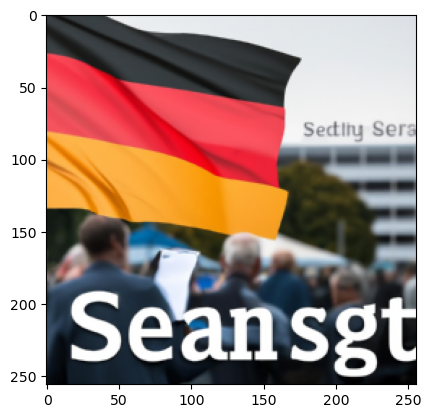

.\store\36.jpg
PADoc[uid:42,name:None,user:21,ts:2023-06-15 07:55:33.903329][{
    "title": "Germany Adopts a National Security Plan. Critics Call It \u2018Weak.\u2019",
    "description": "The country\u2019s first national security strategy is an attempt to set priorities, especially since Russia\u2019s invasion of Ukraine, but hard commitments were short in supply.",
    "ssText": "Caption: a german flag flying over a crowd of people",
    "queue_len": 56,
    "prompt": "produce image generation prompt that summarizes all objects, persons and events from the following news item: news item with title:Germany Adopts a National Security Plan. Critics Call It \u2018Weak.\u2019 and description:The country\u2019s first national security strategy is an attempt to set priorities, especially since Russia\u2019s invasion of Ukraine, but hard commitments were short in supply.",
    "bjImage": "36"
}][fid=28,parent=['39'],usage={'21': 1}]


In [64]:
#test multimedia chain, use 4 API calls in a chain
def test_multimedia_chain():
    G=init_graph()
    
    uid=G.getOrCreateUser("u1")    
    
    #rss source
    fid_rss=G.attachNode({"chain":G.catalogue("FPRss2Text")},uid)
    
    #rss->prompt
    cfg_map={'0':{"ssText":"produce image generation prompt that summarizes all objects, persons and events from the following news item: {{in_doc['ssText']}}"}}
    prompt_t2t=G.composeTransformer([G.catalogue("OIText2Text")],uid,chain_map=cfg_map)
    fid_t2t=G.attachNode({"chain":prompt_t2t},uid,src_id=fid_rss)
    
    #prompt->image
    fid_t2i=G.attachNode({"chain":G.catalogue("OIText2Image")},uid,src_id=fid_t2t)
    
    #image->caption
    fid_i2t=G.attachNode({"chain":G.catalogue("RPImage2Text")},uid,src_id=fid_t2i)
    
    tgt_fid=fid_i2t
    docs=G.consumeFeedDocs(tgt_fid,uid,1) 
    show_docs(docs)
    
test_multimedia_chain()

In [65]:
#subscribe to feed and make sure docs are created and cached
def test_subscription():
    G=init_graph()
    uid1=G.getOrCreateUser("u1")
    uid2=G.getOrCreateUser("u2")
    
    fid11=G.attachNode({"in_doc":{"ssText":"A1"},"chain":G.catalogue("PANull")},uid1)
    fid12=G.attachNode({"in_doc":{"ssText":"A2"},"chain":G.catalogue("PANull")},uid1)
    
    fid21=G.attachNode({"in_doc":{"ssText":"B1"},"chain":G.catalogue("PANull")},uid2)
    fid22=G.attachNode({"in_doc":{"ssText":"B2"},"chain":G.catalogue("PANull")},uid2)
    
    G.updateUserSubs(uid1, {fid11:2,fid21:2,fid22:3})
    G.updateUserSubs(uid2, {fid21:3,fid11:1,fid12:3})
    
    G.consumeAllSubs()
    show_docs(OM.find(otype=PADoc))
    
test_subscription()


showing 33 docs
PADoc[uid:28,name:None,user:28,ts:2023-06-15 07:55:34.076530][{
    "ssText": "NULL[1]A1",
    "params": "{}"
}][fid=24.24[].2[],parent=[],usage={}]
PADoc[uid:29,name:None,user:29,ts:2023-06-15 07:55:34.077531][{
    "ssText": "NULL[1]A1",
    "params": "{}"
}][fid=24.24[],parent=[],usage={}]
PADoc[uid:30,name:None,user:21,ts:2023-06-15 07:55:34.078532][{
    "ssText": "NULL[1]A1",
    "params": "{}"
}][fid=24,parent=[],usage={'21': 1, '22': 1}]
PADoc[uid:31,name:None,user:31,ts:2023-06-15 07:55:34.079535][{
    "ssText": "NULL[2]A1",
    "params": "{}"
}][fid=24.24[].2[],parent=[],usage={}]
PADoc[uid:32,name:None,user:32,ts:2023-06-15 07:55:34.080533][{
    "ssText": "NULL[2]A1",
    "params": "{}"
}][fid=24.24[],parent=[],usage={}]
PADoc[uid:33,name:None,user:21,ts:2023-06-15 07:55:34.081530][{
    "ssText": "NULL[2]A1",
    "params": "{}"
}][fid=24,parent=[],usage={'21': 1, '22': 1}]
PADoc[uid:34,name:None,user:34,ts:2023-06-15 07:55:34.082538][{
    "ssText": "NULL


showing 1 docs


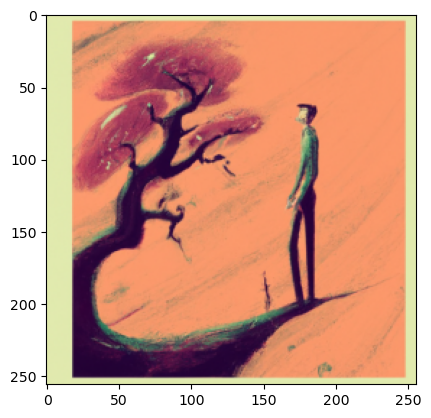

.\store\42.jpg
PADoc[uid:46,name:None,user:21,ts:2023-06-15 07:56:53.374802][{
    "ssText": "\n\n![alt text](https://i.imgur.com/VXTcKV6.jpg \"Dali-style Painting of a Tree with a Man Standing Next to it\")",
    "prompt": "produce Dali-style painting based on: Caption: a painting of a tree with a man standing next to it",
    "bjImage": "42"
}][fid=27,parent=['30'],usage={'21': 1}]


In [66]:
#test really complex transforms
def test_complex_transforms():
    G=init_graph()
    uid=G.getOrCreateUser("u1")
    
    #prompt tranformer
    cfg_map={'0':{"ssText":"produce Dali-style painting based on: {{in_doc['ssText']}}"}}
    prompt_t2t=G.composeTransformer([G.catalogue("OIText2Text")],uid,chain_map=cfg_map)
    
    
    #input->prompt->image->caption->image
    chain=[prompt_t2t,G.catalogue("OIText2Image"),G.catalogue("RPImage2Text"),prompt_t2t,G.catalogue("OIText2Image")]
    double_trans=G.composeTransformer(chain,uid)
    
    #fixed prompt to serve as input
    src_fid=G.attachNode({"in_doc":{"ssText":"describe a content of award winning photograph"},"chain":G.catalogue("OIText2Text")},uid)
    
    #finally a node that used complex transformer attached to haiku source
    hal_fid=G.attachNode({"chain":double_trans},uid,src_id=src_fid)
    
    docs=G.consumeFeedDocs(hal_fid,uid,1) 
    show_docs(docs)
    
test_complex_transforms()